# 🔬 Bangla Fake News Detection using XLM-RoBERTa
## Thesis-Grade Implementation with Full Evaluation Pipeline

**Author:** [Your Name]  
**Dataset:** BanFake — Bangla Fake News Dataset  
**Model:** `xlm-roberta-base` (Cross-lingual Language Model - RoBERTa)  
**Task:** Binary Classification (Fake=0, Real=1)  
**Target Accuracy:** ≥ 95%

---

### 📋 Table of Contents
1. Environment Setup & Library Installation
2. Data Loading & Exploratory Data Analysis (EDA)
3. Data Preprocessing & Cleaning
4. Tokenization with XLM-RoBERTa
5. Dataset Splitting (Train/Val/Test — Stratified)
6. Model Architecture & Configuration
7. Training Loop with Early Stopping, LR Scheduler, Gradient Clipping
8. Overfitting/Underfitting Prevention Techniques
9. Evaluation — Accuracy, F1, Precision, Recall
10. Confusion Matrix (CF)
11. ROC Curve & AUC Score
12. Learning Curves (Loss & Accuracy)
13. Per-Class & Per-Category Analysis
14. Error Analysis
15. Model Saving


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Environment Setup & Library Installation

In [2]:
# ─── Install required libraries ───────────────────────────────────────────────
!pip install transformers torch torchvision torchaudio --quiet
!pip install datasets scikit-learn matplotlib seaborn pandas numpy --quiet
!pip install accelerate sentencepiece --quiet

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [3]:
# ─── Import Libraries ─────────────────────────────────────────────────────────
import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast

from transformers import (
    XLMRobertaTokenizer,
    XLMRobertaForSequenceClassification,
    get_linear_schedule_with_warmup,
    get_cosine_schedule_with_warmup,
    set_seed
)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# ─── Global Settings ──────────────────────────────────────────────────────────
SEED = 42

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

set_global_seed()

# ─── Device Setup ─────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ─── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3
})
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
print("✅ Setup complete!")

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
✅ Setup complete!


## 2. Data Loading & Exploratory Data Analysis (EDA)

In [4]:
# ─── Load Dataset ─────────────────────────────────────────────────────────────
# Update path if running on Google Colab: df = pd.read_csv('/content/BanFake.csv')
DATA_PATH = '/content/drive/MyDrive/dataset/cleanedDatasetFInal.csv'  # Change to your path

df = pd.read_csv(DATA_PATH)

print("━" * 60)
print("📊 DATASET OVERVIEW")
print("━" * 60)
print(f"  Total samples    : {len(df):,}")
print(f"  Total features   : {df.shape[1]}")
print(f"  Columns          : {df.columns.tolist()}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print("━" * 60)
df.head()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total samples    : 48,851
  Total features   : 3
  Columns          : ['Comment', 'Category', 'Cleaned_Text']
  Missing values   : 0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


In [5]:
print("━" * 60)
print("📊 DATASET PREPROCESSING FOR EDA")
print("━" * 60)

# Rename 'Comment ' to 'Comment' for easier access
df = df.rename(columns={'Comment ': 'Comment'})

# Handle missing values in 'Cleaned_Text' and 'Category'
initial_rows = len(df)
df.dropna(subset=['Cleaned_Text', 'Category'], inplace=True)
print(f"  Dropped {initial_rows - len(df):,} rows with missing 'Cleaned_Text' or 'Category' values.")

# Create 'label' column from 'Category'
# Map 'Positive' to 1 (Real) and 'Negative' to 0 (Fake)
# Assuming binary classification with 'Positive' and 'Negative' as categories
category_mapping = {'Positive': 1, 'Negative': 0}
if not all(df['Category'].isin(category_mapping.keys())):
    print("  ⚠️ Warning: 'Category' column contains values other than 'Positive' or 'Negative'. Mapping might be incomplete.")
    # Handle unexpected categories if any, e.g., map them to a neutral or specific class
    df['label'] = df['Category'].map(category_mapping).fillna(-1) # Use -1 for unknown if necessary
else:
    df['label'] = df['Category'].map(category_mapping)
print(f"  Created 'label' column from 'Category': Positive (1), Negative (0)")

# Calculate text length from 'Cleaned_Text'
df['text_length'] = df['Cleaned_Text'].apply(len)
print(f"  Created 'text_length' column from 'Cleaned_Text'.")

print(f"  Current samples    : {len(df):,}")
print(f"  Label distribution : {df['label'].value_counts().to_dict()}")
print("━" * 60)
display(df.head())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 DATASET PREPROCESSING FOR EDA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dropped 0 rows with missing 'Cleaned_Text' or 'Category' values.
  Created 'label' column from 'Category': Positive (1), Negative (0)
  Created 'text_length' column from 'Cleaned_Text'.
  Current samples    : 48,851
  Label distribution : {1: 26729, 0: 22122}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Comment,Category,Cleaned_Text,label,text_length
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ,1,27
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে,1,33
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল,1,21
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা,1,46
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...,1,79


After fixing the data, I will now proceed with the EDA.

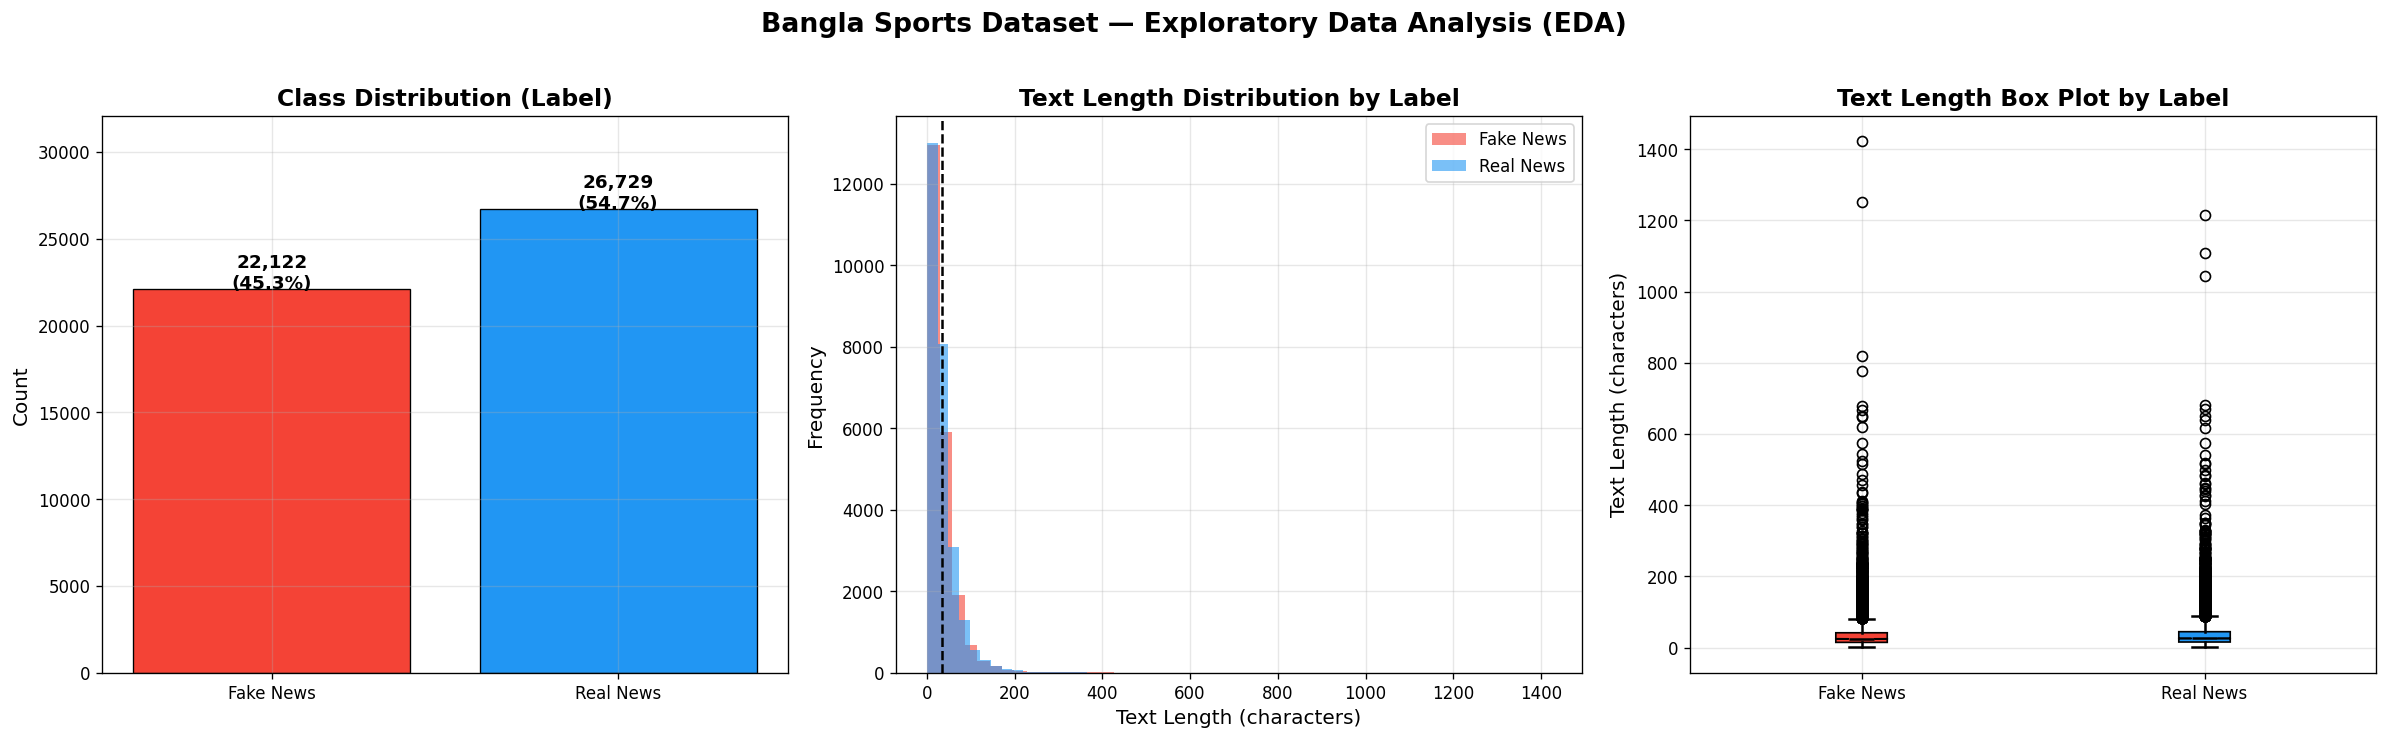

✅ EDA Visualization saved as 'eda_analysis.png'


In [6]:
# ─── EDA Visualizations ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Bangla Sports Dataset — Exploratory Data Analysis (EDA)',
             fontsize=16, fontweight='bold', y=1.02)

# 1. Class distribution
ax1 = axes[0]
label_counts = df['Category'].value_counts() # Use 'Category' column

# Map categories to desired display names and ensure correct color mapping
category_display_names = {'Positive': 'Real News', 'Negative': 'Fake News'}
# Ensure order for plotting (Fake then Real for consistent coloring)
sorted_categories = ['Negative', 'Positive']

# Prepare data for plotting, ensuring categories are in desired order
plot_labels = [category_display_names[cat] for cat in sorted_categories]
plot_counts = [label_counts.get(cat, 0) for cat in sorted_categories]
plot_colors = [PALETTE[1], PALETTE[0]] # Assuming PALETTE[1] for Fake, PALETTE[0] for Real

bars = ax1.bar(plot_labels, plot_counts, color=plot_colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, plot_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Class Distribution (Label)', fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(plot_counts) * 1.2)

# 2. Text length distribution by label
ax2 = axes[1]
for label, color, name in zip([0, 1], [PALETTE[1], PALETTE[0]], ['Fake', 'Real']):
    lengths = df[df['label'] == label]['text_length']
    ax2.hist(lengths, bins=50, alpha=0.6, color=color, label=f'{name} News', edgecolor='none')
ax2.set_title('Text Length Distribution by Label', fontweight='bold')
ax2.set_xlabel('Text Length (characters)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.axvline(df['text_length'].mean(), color='black', linestyle='--', linewidth=1.5, label='Mean')

# 3. Box plot of text length
ax3 = axes[2]
data_for_box = [df[df['label'] == 0]['text_length'], df[df['label'] == 1]['text_length']]
bp = ax3.boxplot(data_for_box, labels=['Fake News', 'Real News'], patch_artist=True,
                 notch=True, vert=True, showfliers=True)
bp['boxes'][0].set_facecolor(PALETTE[1])
bp['boxes'][1].set_facecolor(PALETTE[0])
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='black', linewidth=1.5)
ax3.set_title('Text Length Box Plot by Label', fontweight='bold')
ax3.set_ylabel('Text Length (characters)')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Visualization saved as 'eda_analysis.png'")

In [7]:
# ─── Text Length Statistics ────────────────────────────────────────────────────
print("\n📏 TEXT LENGTH STATISTICS")
print("—" * 45)
for label in [0, 1]:
    lengths = df[df['label'] == label]['text_length']
    name = 'Fake News' if label == 0 else 'Real News'
    print(f"  {name}:")
    print(f"    Mean   : {lengths.mean():.1f} chars")
    print(f"    Median : {lengths.median():.1f} chars")
    print(f"    Std    : {lengths.std():.1f} chars")
    print(f"    Min    : {lengths.min()} chars")
    print(f"    Max    : {lengths.max()} chars")
print("—" * 45)


📏 TEXT LENGTH STATISTICS
—————————————————————————————————————————————
  Fake News:
    Mean   : 34.9 chars
    Median : 25.0 chars
    Std    : 38.3 chars
    Min    : 1 chars
    Max    : 1422 chars
  Real News:
    Mean   : 36.3 chars
    Median : 26.0 chars
    Std    : 37.0 chars
    Min    : 1 chars
    Max    : 1214 chars
—————————————————————————————————————————————


## 3. Data Preprocessing & Cleaning

In [8]:
# ─── Text Cleaning ────────────────────────────────────────────────────────────
def clean_bangla_text(text):
    """
    Bangla text cleaning pipeline:
      - Remove URLs, HTML tags, special chars
      - Normalize whitespace
      - Keep Bangla Unicode range (\u0980-\u09FF) + common punctuation
    """
    if not isinstance(text, str):
        return ""
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove excessive punctuation repetition
    text = re.sub(r'([।!?]){2,}', r'\1', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ─── Create combined text field from 'Cleaned_Text' ───────────────────────
# The current dataset only has 'Cleaned_Text', so we'll use that directly.
df['combined_text'] = df['Cleaned_Text'].fillna('').apply(clean_bangla_text)

# Remove empty rows
df = df[df['combined_text'].str.len() > 10].reset_index(drop=True)

print(f"✅ After cleaning: {len(df):,} samples")
print(f"   Label distribution: {dict(df['label'].value_counts().sort_index())}")
print("\n📝 Sample cleaned text:")
print(f"   Fake: {df[df['label']==0]['combined_text'].iloc[0][:120]}...")
print(f"   Real: {df[df['label']==1]['combined_text'].iloc[0][:120]}...")

✅ After cleaning: 42,671 samples
   Label distribution: {0: np.int64(19013), 1: np.int64(23658)}

📝 Sample cleaned text:
   Fake: হিংসা মাথা খারাপ হয়...
   Real: মন হয় পাড়া মহল্ল খেলা দেখ...


## 4. Configuration & Hyperparameters

In [9]:
# ─── Hyperparameter Configuration ─────────────────────────────────────────────
CONFIG = {
    # Model
    'model_name'        : 'xlm-roberta-base',
    'num_labels'        : 2,
    'max_length'        : 256,        # Token limit (covers ~95% of texts)

    # Training
    'batch_size'        : 16,         # Reduce to 8 if GPU OOM
    'num_epochs'        : 10,
    'learning_rate'     : 2e-5,       # Standard for fine-tuning BERT-family
    'weight_decay'      : 0.01,       # L2 regularization
    'warmup_ratio'      : 0.1,        # 10% warmup steps
    'max_grad_norm'     : 1.0,        # Gradient clipping

    # Regularization (Overfitting Prevention)
    'dropout_rate'      : 0.3,        # Classifier dropout
    'hidden_dropout'    : 0.1,        # Transformer hidden dropout
    'attention_dropout' : 0.1,        # Attention dropout

    # Data splits
    'train_ratio'       : 0.70,
    'val_ratio'         : 0.15,
    'test_ratio'        : 0.15,

    # Early Stopping
    'patience'          : 3,          # Stop if no improvement for N epochs
    'min_delta'         : 0.001,

    # Mixed precision
    'use_amp'           : torch.cuda.is_available(),

    # Scheduler type
    'scheduler'         : 'cosine',   # 'linear' or 'cosine'

    'seed'              : SEED,
    'save_dir'          : './xlmr_banfake_model'
}

os.makedirs(CONFIG['save_dir'], exist_ok=True)

print("⚙️  CONFIGURATION")
print("━" * 40)
for k, v in CONFIG.items():
    print(f"   {k:<22}: {v}")
print("━" * 40)

⚙️  CONFIGURATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   model_name            : xlm-roberta-base
   num_labels            : 2
   max_length            : 256
   batch_size            : 16
   num_epochs            : 10
   learning_rate         : 2e-05
   weight_decay          : 0.01
   warmup_ratio          : 0.1
   max_grad_norm         : 1.0
   dropout_rate          : 0.3
   hidden_dropout        : 0.1
   attention_dropout     : 0.1
   train_ratio           : 0.7
   val_ratio             : 0.15
   test_ratio            : 0.15
   patience              : 3
   min_delta             : 0.001
   use_amp               : True
   scheduler             : cosine
   seed                  : 42
   save_dir              : ./xlmr_banfake_model
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 5. Dataset Splitting (Stratified Train/Val/Test)

📂 DATA SPLITS (Stratified)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train : 29869 samples | Fake=13309 (44.6%) | Real=16560 (55.4%)
  Val   :  6401 samples | Fake=2852 (44.6%) | Real=3549 (55.4%)
  Test  :  6401 samples | Fake=2852 (44.6%) | Real=3549 (55.4%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


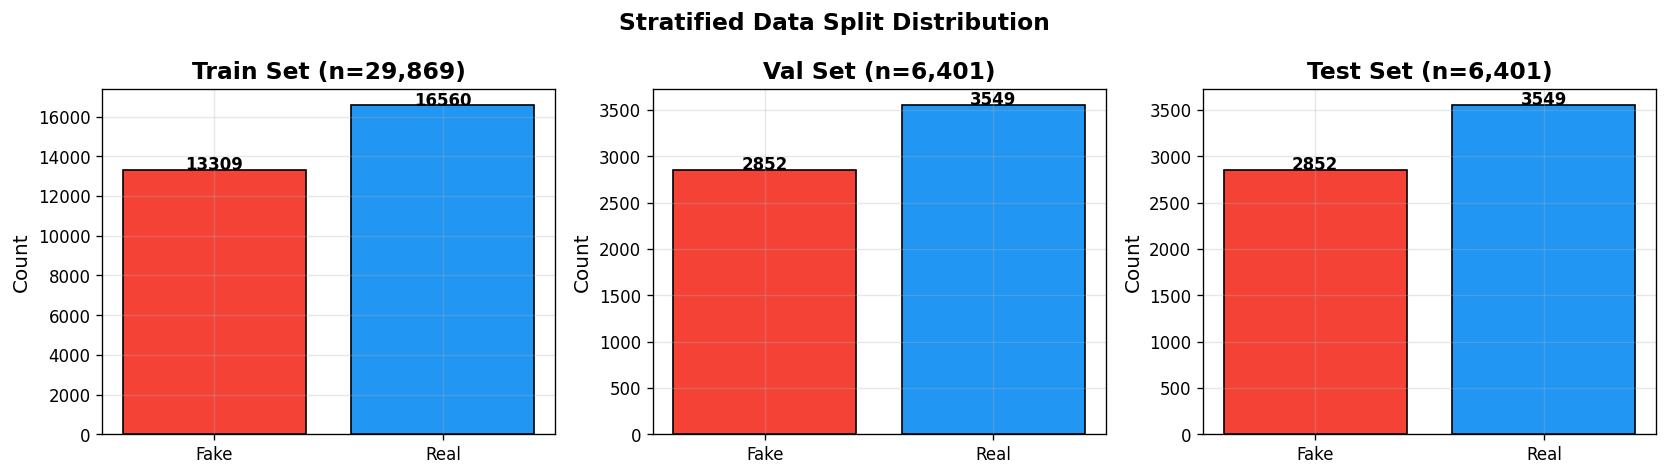

In [10]:
# ─── Stratified Split: 70% Train | 15% Val | 15% Test ─────────────────────────
texts  = df['combined_text'].tolist()
labels = df['label'].tolist()

# Step 1: Train vs (Val + Test)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels,
    test_size  = (1 - CONFIG['train_ratio']),
    random_state = SEED,
    stratify   = labels
)

# Step 2: Val vs Test from the temp split
val_size = CONFIG['val_ratio'] / (CONFIG['val_ratio'] + CONFIG['test_ratio'])
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size  = (1 - val_size),
    random_state = SEED,
    stratify   = temp_labels
)

print("📂 DATA SPLITS (Stratified)")
print("━" * 48)
for split, lbls in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    c = Counter(lbls)
    total = len(lbls)
    print(f"  {split:<6}: {total:>5} samples | Fake={c[0]:>4} ({c[0]/total*100:.1f}%) | Real={c[1]:>4} ({c[1]/total*100:.1f}%)")
print("━" * 48)

# Visualize splits
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Stratified Data Split Distribution', fontsize=14, fontweight='bold')
for ax, (split, lbls) in zip(axes, [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]):
    c = Counter(lbls)
    ax.bar(['Fake', 'Real'], [c[0], c[1]], color=[PALETTE[1], PALETTE[0]], edgecolor='black')
    ax.set_title(f'{split} Set (n={len(lbls):,})', fontweight='bold')
    ax.set_ylabel('Count')
    for i, (k, v) in enumerate([(0, c[0]), (1, c[1])]):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tokenization & PyTorch Dataset

In [11]:
# ─── Load XLM-RoBERTa Tokenizer ───────────────────────────────────────────────
print(f"⏳ Loading tokenizer: {CONFIG['model_name']}...")
tokenizer = XLMRobertaTokenizer.from_pretrained(CONFIG['model_name'])
print(f"✅ Tokenizer loaded! Vocab size: {tokenizer.vocab_size:,}")

# ─── Token length analysis ────────────────────────────────────────────────────
sample_lengths = [len(tokenizer.encode(t, truncation=False)) for t in texts[:500]]
pct_95 = np.percentile(sample_lengths, 95)
pct_99 = np.percentile(sample_lengths, 99)
print(f"\n📏 Token Length Stats (sample of 500):")
print(f"   Mean   : {np.mean(sample_lengths):.1f} tokens")
print(f"   95th % : {pct_95:.0f} tokens")
print(f"   99th % : {pct_99:.0f} tokens")
print(f"   Max used: {CONFIG['max_length']} (covers {np.mean([l <= CONFIG['max_length'] for l in sample_lengths])*100:.1f}% of samples)")

⏳ Loading tokenizer: xlm-roberta-base...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded! Vocab size: 250,002

📏 Token Length Stats (sample of 500):
   Mean   : 16.6 tokens
   95th % : 39 tokens
   99th % : 68 tokens
   Max used: 256 (covers 100.0% of samples)


In [12]:
# ─── PyTorch Dataset Class ────────────────────────────────────────────────────
class BanFakeDataset(Dataset):
    """Custom Dataset for BanFake — tokenizes text on the fly."""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_length,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ─── Create Datasets ──────────────────────────────────────────────────────────
train_dataset = BanFakeDataset(train_texts, train_labels, tokenizer, CONFIG['max_length'])
val_dataset   = BanFakeDataset(val_texts,   val_labels,   tokenizer, CONFIG['max_length'])
test_dataset  = BanFakeDataset(test_texts,  test_labels,  tokenizer, CONFIG['max_length'])

# ─── Create DataLoaders ───────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True if DEVICE.type=='cuda' else False)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size']*2, shuffle=False,
                          num_workers=2, pin_memory=True if DEVICE.type=='cuda' else False)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size']*2, shuffle=False,
                          num_workers=2, pin_memory=True if DEVICE.type=='cuda' else False)

print(f"✅ DataLoaders ready!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ DataLoaders ready!
   Train batches : 1867
   Val batches   : 201
   Test batches  : 201


## 7. Model Architecture — XLM-RoBERTa with Custom Classifier Head

In [13]:
from transformers import XLMRobertaModel
from transformers.modeling_outputs import SequenceClassifierOutput # Import for consistent output type

# ─── Custom XLM-RoBERTa Classifier ───────────────────────────────────────────
class XLMRoBertaFakeNewsClassifier(nn.Module):
    """
    XLM-RoBERTa with enhanced classification head.

    Architecture:
      XLM-RoBERTa (768-dim) → LayerNorm → Dropout → Linear(512) → GELU
      → LayerNorm → Dropout → Linear(2)

    Overfitting Prevention:
      • Dropout in transformer layers (hidden + attention)
      • Dropout in classifier head
      • LayerNorm for stable training
      • Weight decay via AdamW optimizer
    """

    def __init__(self, model_name, num_labels=2, dropout_rate=0.3,
                 hidden_dropout=0.1, attention_dropout=0.1):
        super().__init__()

        # Load the base XLM-RoBERTa model, not the sequence classification version
        self.xlmr = XLMRobertaModel.from_pretrained(
            model_name,
            hidden_dropout_prob  = hidden_dropout,
            attention_probs_dropout_prob = attention_dropout
        )
        self.num_labels = num_labels
        hidden_size = self.xlmr.config.hidden_size  # 768 for base

        # Our custom classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_labels)
        )
        self.loss_fct = nn.CrossEntropyLoss() # Define loss function explicitly

    def forward(self, input_ids, attention_mask, labels=None):
        # Get outputs from the base XLM-RoBERTa model
        # `outputs` will be a BaseModelOutputWithPoolingAndCrossAttentions or similar
        outputs = self.xlmr(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        # Extract the representation of the [CLS] token (first token in the sequence)
        # This is the standard way to get a fixed-size representation for sequence classification
        pooled_output = outputs.last_hidden_state[:, 0, :]

        # Pass the pooled output through our custom classifier
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            # `logits` has shape (batch_size, num_labels)
            # `labels` has shape (batch_size)
            # CrossEntropyLoss expects input (N, C) and target (N)
            loss = self.loss_fct(logits, labels)

        # Return a SequenceClassifierOutput for compatibility with training loop
        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states, # Optional, for full compatibility
            attentions=outputs.attentions # Optional
        )

# ─── Initialize Model ─────────────────────────────────────────────────────────
print(f"⏳ Loading model: {CONFIG['model_name']}...")
model = XLMRoBertaFakeNewsClassifier(
    model_name        = CONFIG['model_name'],
    num_labels        = CONFIG['num_labels'],
    dropout_rate      = CONFIG['dropout_rate'],
    hidden_dropout    = CONFIG['hidden_dropout'],
    attention_dropout = CONFIG['attention_dropout']
).to(DEVICE)

# Model parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model loaded!")
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Non-trainable       : {total_params - trainable_params:,}")

⏳ Loading model: xlm-roberta-base...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded!
   Total parameters    : 278,440,962
   Trainable parameters: 278,440,962
   Non-trainable       : 0


## 8. Optimizer, Scheduler & Training Utilities

In [14]:
# ─── Optimizer: AdamW with differential learning rates ────────────────────────
# Technique: Lower LR for pre-trained transformer layers, higher for new head
no_decay = ['bias', 'LayerNorm.weight', 'layer_norm.weight']

optimizer_grouped_parameters = [
    # Transformer layers — with weight decay, lower LR
    {'params': [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay) and 'classifier' not in n],
     'weight_decay': CONFIG['weight_decay'],
     'lr': CONFIG['learning_rate']},
    # Transformer layers — no weight decay
    {'params': [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay) and 'classifier' not in n],
     'weight_decay': 0.0,
     'lr': CONFIG['learning_rate']},
    # Classifier head — higher LR (new weights need faster learning)
    {'params': [p for n, p in model.named_parameters() if 'classifier' in n],
     'weight_decay': CONFIG['weight_decay'],
     'lr': CONFIG['learning_rate'] * 10},
]

optimizer = AdamW(optimizer_grouped_parameters, eps=1e-8)

# ─── Learning Rate Scheduler ──────────────────────────────────────────────────
total_steps  = len(train_loader) * CONFIG['num_epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

if CONFIG['scheduler'] == 'cosine':
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
else:
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

# ─── Mixed Precision Scaler ───────────────────────────────────────────────────
scaler = GradScaler(enabled=CONFIG['use_amp'])

print(f"✅ Optimizer & Scheduler configured!")
print(f"   Total training steps : {total_steps:,}")
print(f"   Warmup steps         : {warmup_steps:,}")
print(f"   Scheduler type       : {CONFIG['scheduler']}")
print(f"   Mixed precision (AMP): {CONFIG['use_amp']}")

✅ Optimizer & Scheduler configured!
   Total training steps : 18,670
   Warmup steps         : 1,867
   Scheduler type       : cosine
   Mixed precision (AMP): True


In [15]:
# ─── Training & Evaluation Helper Functions ───────────────────────────────────

class EarlyStopping:
    """Early stopping to prevent overfitting."""
    def __init__(self, patience=3, min_delta=0.001, mode='max'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif (self.mode == 'max' and score < self.best_score + self.min_delta) or \
             (self.mode == 'min' and score > self.best_score - self.min_delta):
            self.counter += 1
            print(f"   ⚠️  EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter    = 0


def train_one_epoch(model, loader, optimizer, scheduler, scaler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        with autocast(enabled=CONFIG['use_amp']):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss

        # Check for NaN/Inf loss before scaling and backward pass
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"WARNING: Non-finite loss {loss.item()} detected in batch {batch_idx}. Skipping optimizer step for this batch.")
            continue # Skip to the next batch

        scaler.scale(loss).backward()
        # Gradient clipping — applied to scaled gradients (compromise to fix RuntimeError)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['max_grad_norm'])
        scaler.step(optimizer)
        scaler.update() # Re-added scaler.update() to correctly manage the GradScaler state
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, f1


@torch.no_grad()
def evaluate(model, loader, device, return_probs=False):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], [] # Fixed: Initialized all_probs

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        with autocast(enabled=CONFIG['use_amp']):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        total_loss += outputs.loss.item()
        probs  = torch.softmax(outputs.logits, dim=-1)
        preds  = torch.argmax(outputs.logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted')

    if return_probs:
        return avg_loss, accuracy, f1, all_preds, all_labels, np.array(all_probs)
    return avg_loss, accuracy, f1


print("✅ Training utilities defined!")

✅ Training utilities defined!


## 9. Training Loop

In [16]:
# ─── Training Loop ────────────────────────────────────────────────────────────
print("🚀 STARTING TRAINING")
print("━" * 65)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>7} | {'LR':>10}")
print("━" * 65)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'train_f1'  : [], 'val_f1'  : [],
    'lr'        : []
}

early_stopping = EarlyStopping(patience=CONFIG['patience'], mode='max')
best_val_acc   = 0.0
best_val_f1    = 0.0
best_epoch     = 0

for epoch in range(1, CONFIG['num_epochs'] + 1):
    # Train
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, DEVICE)

    # Validate
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, DEVICE)

    # Current LR
    current_lr = scheduler.get_last_lr()[0]

    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_f1  = val_f1
        best_epoch   = epoch
        torch.save(model.state_dict(), os.path.join(CONFIG['save_dir'], 'best_model.pt'))
        status = '✅ BEST'
    else:
        status = ''

    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>6.4f} | {current_lr:>10.2e}  {status}")

    # Early stopping check
    early_stopping(val_acc)
    if early_stopping.stop:
        print(f"\n🛑 Early stopping triggered at epoch {epoch}!")
        break

print("━" * 65)
print(f"\n🏆 Best model: Epoch {best_epoch} | Val Acc={best_val_acc:.4f} | Val F1={best_val_f1:.4f}")

🚀 STARTING TRAINING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Epoch | Train Loss | Train Acc | Val Loss | Val Acc |  Val F1 |         LR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    1 |     0.6746 |   0.5895 |   0.6070 |  0.6638 | 0.6627 |   2.00e-05  ✅ BEST
    2 |     0.5896 |   0.6827 |   0.5773 |  0.7013 | 0.7016 |   1.94e-05  ✅ BEST
    3 |     0.5520 |   0.7196 |   0.5765 |  0.7049 | 0.7057 |   1.77e-05  ✅ BEST
    4 |     0.5185 |   0.7441 |   0.6065 |  0.7018 | 0.7017 |   1.50e-05  
   ⚠️  EarlyStopping: 1/3
    5 |     0.4907 |   0.7639 |   0.6370 |  0.7021 | 0.7011 |   1.17e-05  
   ⚠️  EarlyStopping: 2/3
    6 |     0.4699 |   0.7790 |   0.6192 |  0.6986 | 0.6984 |   8.26e-06  
   ⚠️  EarlyStopping: 3/3

🛑 Early stopping triggered at epoch 6!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 Best model: Epoch 3 | Val Acc=0.7049 | Val F1=0.7057


## 10. Learning Curves

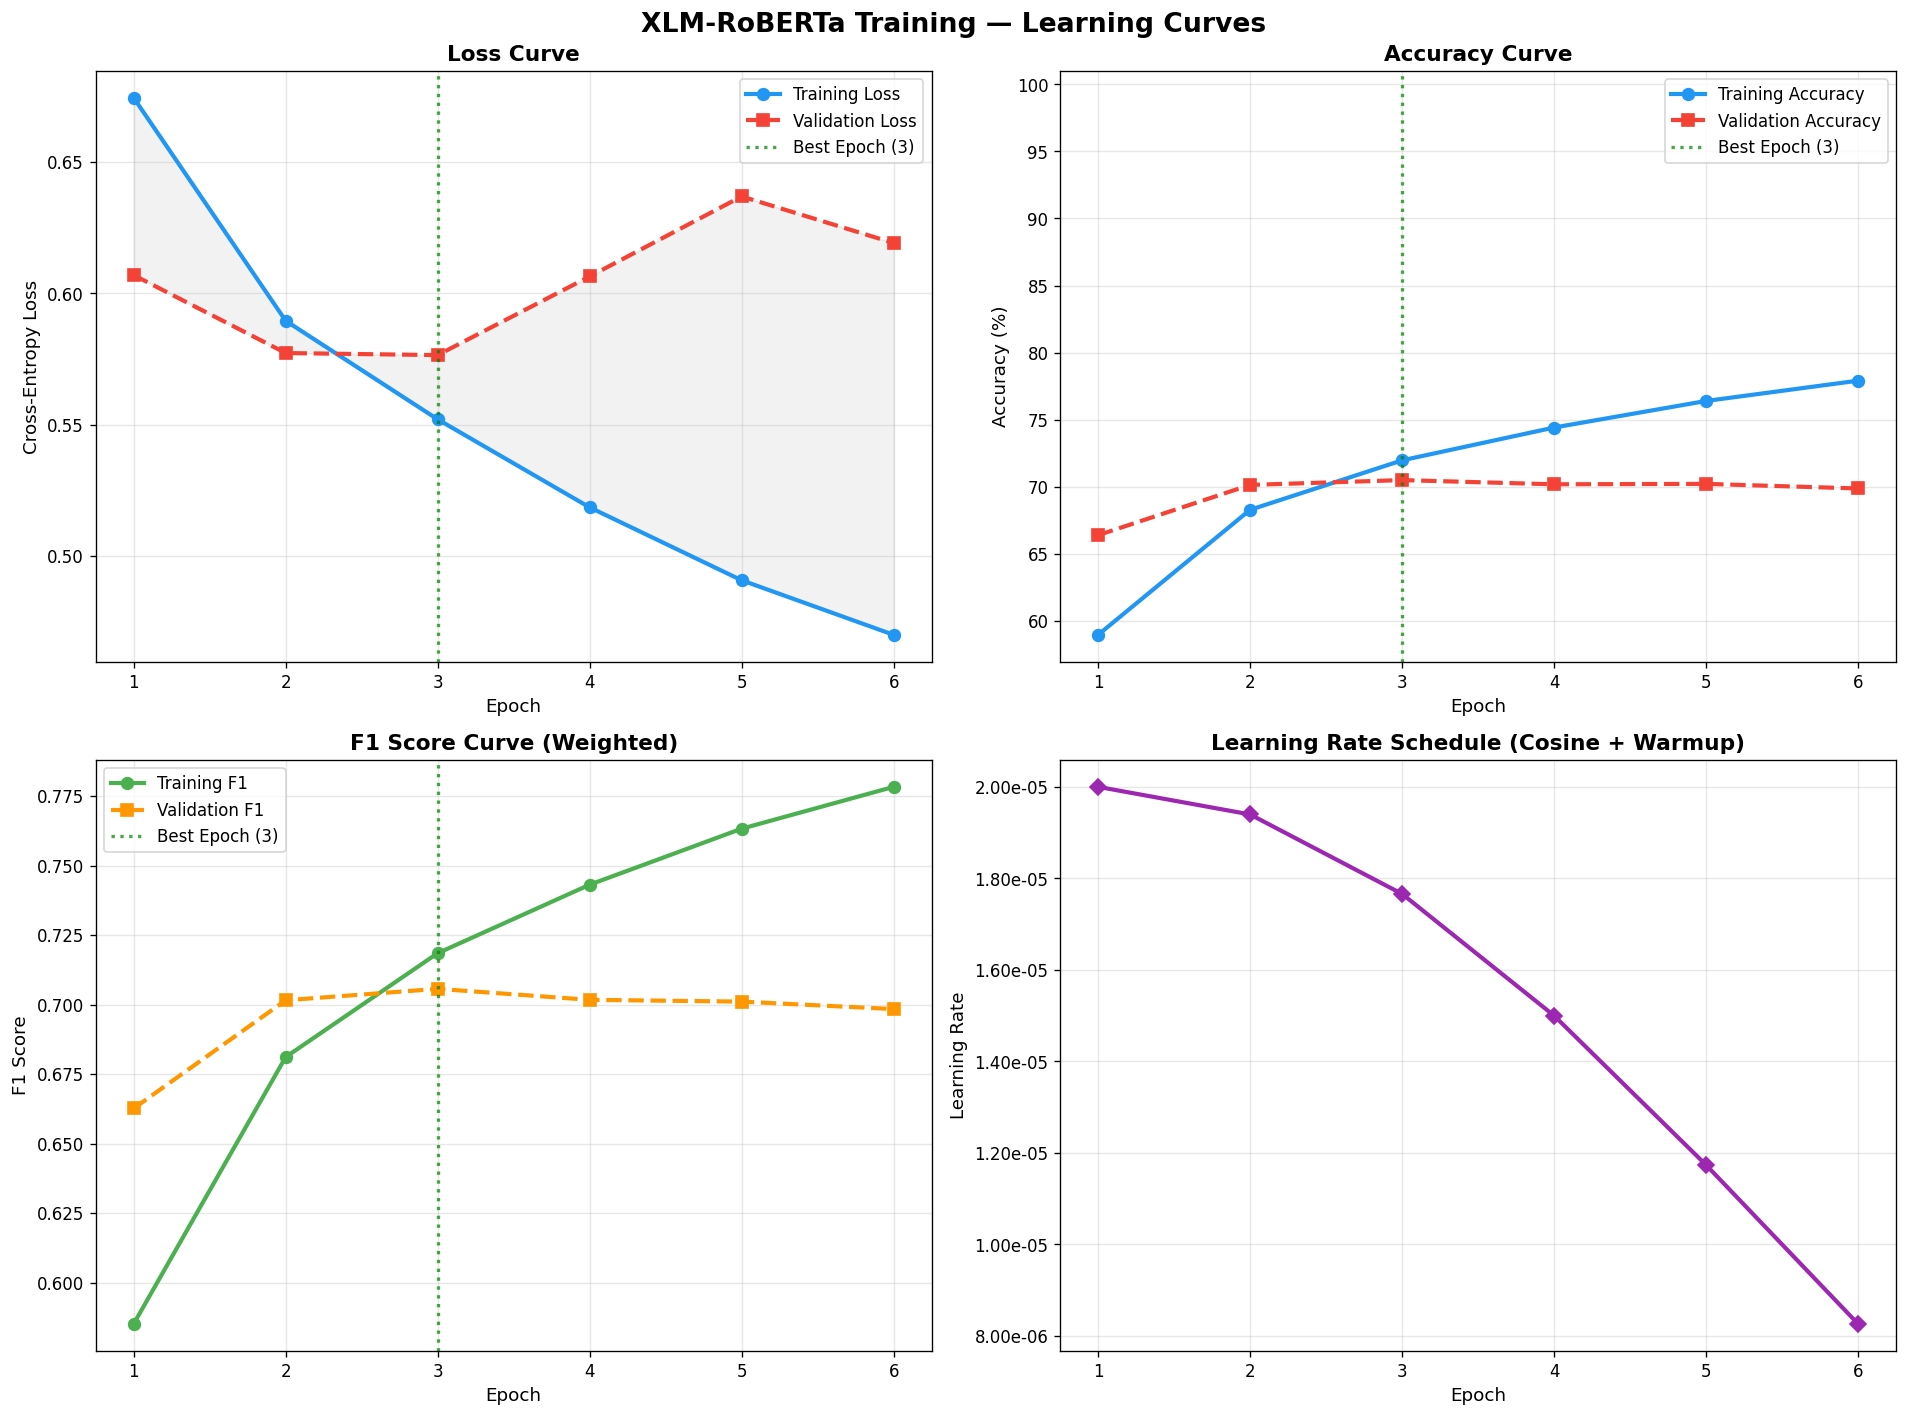

✅ Learning curves saved as 'learning_curves.png'


In [17]:
# ─── Learning Curves — Loss, Accuracy, F1, Learning Rate ─────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('XLM-RoBERTa Training — Learning Curves', fontsize=16, fontweight='bold')

# ── 1. Loss Curve ──
ax1 = axes[0, 0]
ax1.plot(epochs_range, history['train_loss'], 'o-', color=PALETTE[0],
         linewidth=2.5, markersize=7, label='Training Loss')
ax1.plot(epochs_range, history['val_loss'], 's--', color=PALETTE[1],
         linewidth=2.5, markersize=7, label='Validation Loss')
ax1.axvline(best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax1.fill_between(epochs_range, history['train_loss'], history['val_loss'],
                 alpha=0.1, color='gray')
ax1.set_title('Loss Curve', fontweight='bold', fontsize=13)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── 2. Accuracy Curve ──
ax2 = axes[0, 1]
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', color=PALETTE[0],
         linewidth=2.5, markersize=7, label='Training Accuracy')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']], 's--', color=PALETTE[1],
         linewidth=2.5, markersize=7, label='Validation Accuracy')
ax2.axvline(best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax2.set_title('Accuracy Curve', fontweight='bold', fontsize=13)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.legend(fontsize=10)
ax2.set_ylim([min(min(history['train_acc']), min(history['val_acc']))*100 - 2, 101])
ax2.grid(True, alpha=0.3)

# ── 3. F1 Score Curve ──
ax3 = axes[1, 0]
ax3.plot(epochs_range, history['train_f1'], 'o-', color=PALETTE[2],
         linewidth=2.5, markersize=7, label='Training F1')
ax3.plot(epochs_range, history['val_f1'], 's--', color=PALETTE[3],
         linewidth=2.5, markersize=7, label='Validation F1')
ax3.axvline(best_epoch, color='green', linestyle=':', linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax3.set_title('F1 Score Curve (Weighted)', fontweight='bold', fontsize=13)
ax3.set_xlabel('Epoch', fontsize=11)
ax3.set_ylabel('F1 Score', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# ── 4. Learning Rate Schedule ──
ax4 = axes[1, 1]
ax4.plot(epochs_range, history['lr'], 'D-', color=PALETTE[4],
         linewidth=2.5, markersize=7)
ax4.set_title(f'Learning Rate Schedule ({CONFIG["scheduler"].capitalize()} + Warmup)',
              fontweight='bold', fontsize=13)
ax4.set_xlabel('Epoch', fontsize=11)
ax4.set_ylabel('Learning Rate', fontsize=11)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2e}'))
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Learning curves saved as 'learning_curves.png'")

In [18]:
# ─── Overfitting Diagnostic ───────────────────────────────────────────────────
print("\n🔍 OVERFITTING / UNDERFITTING DIAGNOSTIC")
print("━" * 55)

final_train_acc = history['train_acc'][-1]
final_val_acc   = history['val_acc'][-1]
gap             = final_train_acc - final_val_acc

print(f"   Final Train Accuracy : {final_train_acc*100:.2f}%")
print(f"   Final Val   Accuracy : {final_val_acc*100:.2f}%")
print(f"   Train-Val Gap        : {gap*100:.2f}%")

if gap > 0.10:
    diagnosis = "⚠️  OVERFITTING detected (gap > 10%)"
    suggestion = "→ Increase dropout, reduce epochs, add data augmentation"
elif final_train_acc < 0.85 and final_val_acc < 0.85:
    diagnosis = "⚠️  UNDERFITTING detected (both low accuracy)"
    suggestion = "→ Train longer, reduce dropout, use larger model"
elif gap < 0.05:
    diagnosis = "✅ GOOD FIT (train-val gap < 5%)"
    suggestion = "→ Model generalizes well"
else:
    diagnosis = "⚠️  MILD OVERFITTING (gap 5-10%)"
    suggestion = "→ Slight regularization improvement possible"

print(f"\n   Diagnosis  : {diagnosis}")
print(f"   Suggestion : {suggestion}")
print("━" * 55)


🔍 OVERFITTING / UNDERFITTING DIAGNOSTIC
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Final Train Accuracy : 77.90%
   Final Val   Accuracy : 69.86%
   Train-Val Gap        : 8.04%

   Diagnosis  : ⚠️  UNDERFITTING detected (both low accuracy)
   Suggestion : → Train longer, reduce dropout, use larger model
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 11. Final Evaluation on Test Set

In [19]:
# ─── Load Best Model & Evaluate on Test Set ───────────────────────────────────
print("⏳ Loading best saved model...")
best_model = XLMRoBertaFakeNewsClassifier(
    model_name        = CONFIG['model_name'],
    num_labels        = CONFIG['num_labels'],
    dropout_rate      = CONFIG['dropout_rate'],
    hidden_dropout    = CONFIG['hidden_dropout'],
    attention_dropout = CONFIG['attention_dropout']
).to(DEVICE)

best_model.load_state_dict(torch.load(
    os.path.join(CONFIG['save_dir'], 'best_model.pt'),
    map_location=DEVICE
))

print("✅ Best model loaded!")

# Full evaluation on test set
test_loss, test_acc, test_f1, test_preds, test_true, test_probs = evaluate(
    best_model, test_loader, DEVICE, return_probs=True
)

precision = precision_score(test_true, test_preds, average='weighted')
recall    = recall_score(test_true, test_preds, average='weighted')
auc_score = roc_auc_score(test_true, test_probs[:, 1])

print("\n" + "━" * 45)
print("📊 TEST SET RESULTS (Best Model)")
print("━" * 45)
print(f"   Test Loss      : {test_loss:.4f}")
print(f"   Test Accuracy  : {test_acc*100:.2f}%", "✅" if test_acc >= 0.95 else "")
print(f"   Test F1 (W)    : {test_f1:.4f}")
print(f"   Test Precision : {precision:.4f}")
print(f"   Test Recall    : {recall:.4f}")
print(f"   ROC-AUC Score  : {auc_score:.4f}")
print("━" * 45)

⏳ Loading best saved model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Best model loaded!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 TEST SET RESULTS (Best Model)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Test Loss      : 0.5722
   Test Accuracy  : 70.79% 
   Test F1 (W)    : 0.7086
   Test Precision : 0.7111
   Test Recall    : 0.7079
   ROC-AUC Score  : 0.7798
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [20]:
# ─── Detailed Classification Report ──────────────────────────────────────────
target_names = ['Negative', 'Positive']
report = classification_report(test_true, test_preds, target_names=target_names, digits=4)
print("📋 DETAILED CLASSIFICATION REPORT")
print("━" * 65)
print(report)
print("━" * 65)

📋 DETAILED CLASSIFICATION REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

    Negative     0.6595    0.7118    0.6847      2852
    Positive     0.7526    0.7047    0.7279      3549

    accuracy                         0.7079      6401
   macro avg     0.7061    0.7082    0.7063      6401
weighted avg     0.7111    0.7079    0.7086      6401

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 12. Confusion Matrix

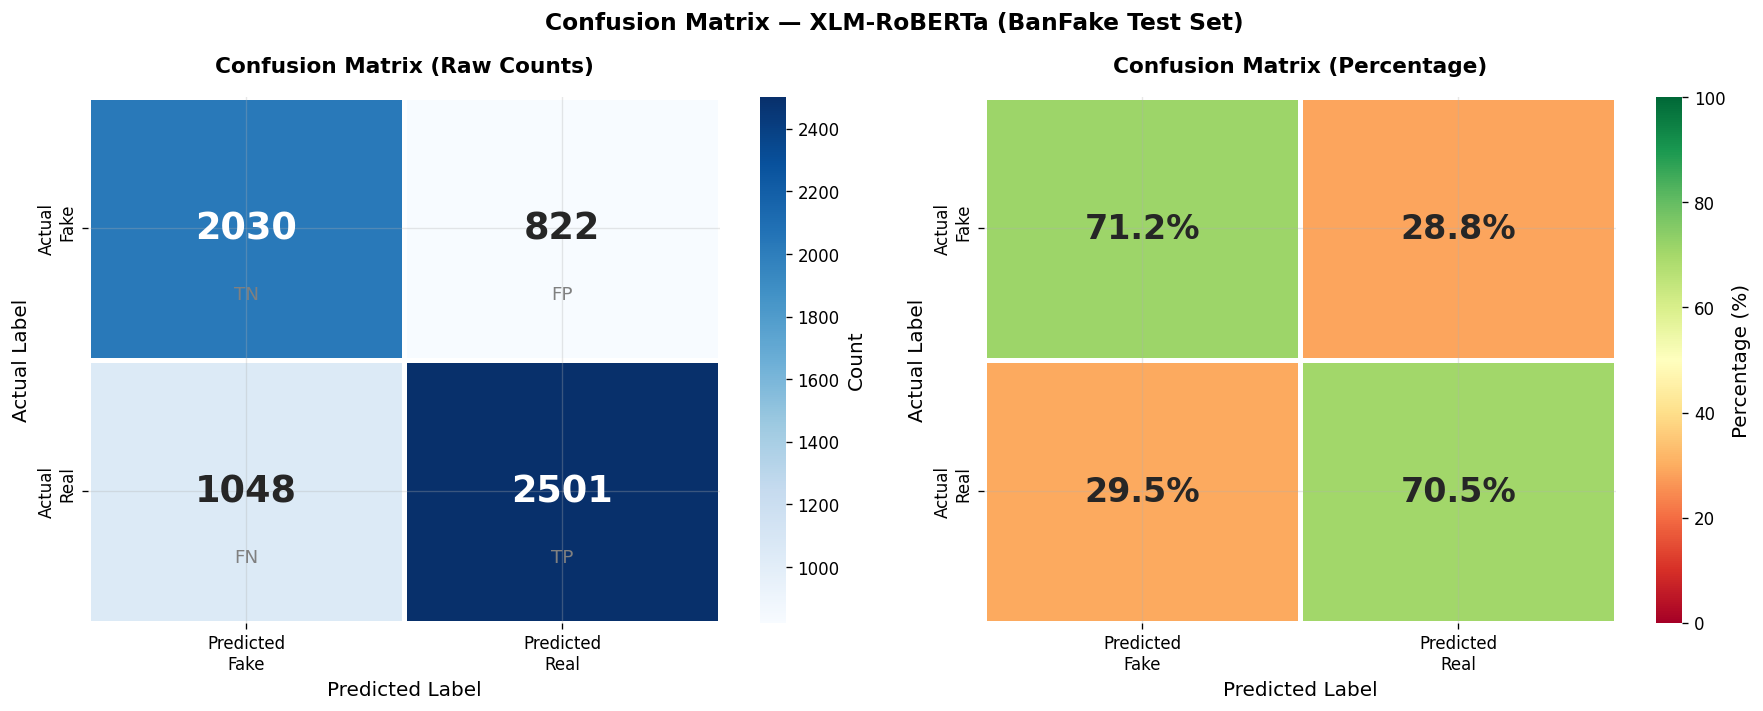


📊 CM Breakdown:
   True Positives  (TP):  2501 — Real news correctly identified
   True Negatives  (TN):  2030 — Fake news correctly identified
   False Positives (FP):   822 — Fake news misclassified as Real
   False Negatives (FN):  1048 — Real news misclassified as Fake

   Specificity : 0.7118
   Sensitivity : 0.7047
✅ Confusion matrix saved!


In [21]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm     = confusion_matrix(test_true, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confusion Matrix — XLM-RoBERTa (BanFake Test Set)',
             fontsize=14, fontweight='bold')

# ── Raw counts ──
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted\nFake', 'Predicted\nReal'],
            yticklabels=['Actual\nFake', 'Actual\nReal'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 22, 'weight': 'bold'}, ax=ax1,
            cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Actual Label', fontsize=12)
ax1.set_xlabel('Predicted Label', fontsize=12)

# Annotate TP/TN/FP/FN labels
labels_cf = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax1.text(j + 0.5, i + 0.75, labels_cf[i][j],
                 ha='center', va='center', color='gray', fontsize=11)

# ── Percentage ──
ax2 = axes[1]
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=['Predicted\nFake', 'Predicted\nReal'],
            yticklabels=['Actual\nFake', 'Actual\nReal'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 20, 'weight': 'bold'}, ax=ax2,
            cbar_kws={'label': 'Percentage (%)'},
            vmin=0, vmax=100)
ax2.set_title('Confusion Matrix (Percentage)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Actual Label', fontsize=12)
ax2.set_xlabel('Predicted Label', fontsize=12)

# Add % symbol to annotations
for text in ax2.texts:
    text.set_text(text.get_text() + '%')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n📊 CM Breakdown:")
print(f"   True Positives  (TP): {tp:>5} — Real news correctly identified")
print(f"   True Negatives  (TN): {tn:>5} — Fake news correctly identified")
print(f"   False Positives (FP): {fp:>5} — Fake news misclassified as Real")
print(f"   False Negatives (FN): {fn:>5} — Real news misclassified as Fake")
print(f"\n   Specificity : {tn/(tn+fp):.4f}")
print(f"   Sensitivity : {tp/(tp+fn):.4f}")
print("✅ Confusion matrix saved!")

## 13. ROC Curve & AUC

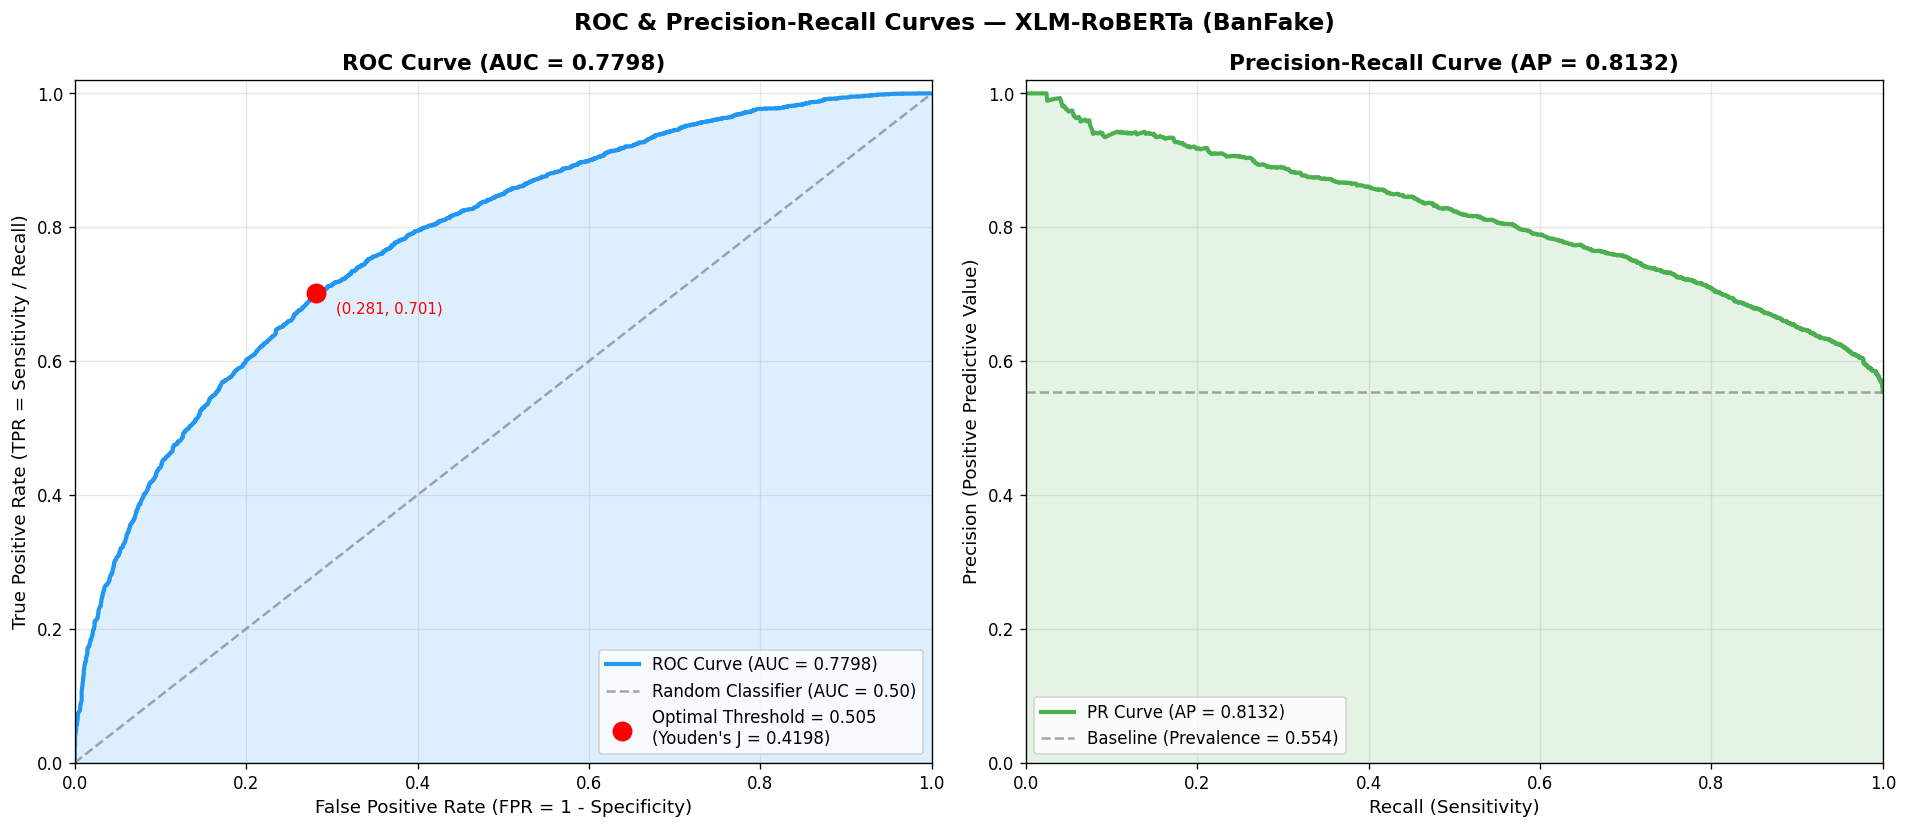

✅ ROC-AUC = 0.7798 | Average Precision = 0.8132
   ROC-AUC curve saved as 'roc_auc_curve.png'


In [22]:
# ─── ROC Curve, AUC, Precision-Recall Curve ───────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(test_true, test_probs[:, 1])
auc_val                  = roc_auc_score(test_true, test_probs[:, 1])

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(test_true, test_probs[:, 1])
avg_precision                              = average_precision_score(test_true, test_probs[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ROC & Precision-Recall Curves — XLM-RoBERTa (BanFake)',
             fontsize=14, fontweight='bold')

# ── ROC Curve ──
ax1 = axes[0]
ax1.plot(fpr, tpr, color=PALETTE[0], lw=2.5,
         label=f'ROC Curve (AUC = {auc_val:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', alpha=0.7,
         label='Random Classifier (AUC = 0.50)')
ax1.fill_between(fpr, tpr, alpha=0.15, color=PALETTE[0])

# Mark optimal threshold (Youden's J)
j_scores  = tpr - fpr
best_idx  = np.argmax(j_scores)
ax1.scatter(fpr[best_idx], tpr[best_idx], s=120, color='red', zorder=5,
            label=f'Optimal Threshold = {roc_thresholds[best_idx]:.3f}\n(Youden\'s J = {j_scores[best_idx]:.4f})')
ax1.annotate(f'({fpr[best_idx]:.3f}, {tpr[best_idx]:.3f})',
             (fpr[best_idx], tpr[best_idx]),
             textcoords='offset points', xytext=(12, -12),
             fontsize=9, color='red')

ax1.set_title(f'ROC Curve (AUC = {auc_val:.4f})', fontweight='bold', fontsize=13)
ax1.set_xlabel('False Positive Rate (FPR = 1 - Specificity)', fontsize=11)
ax1.set_ylabel('True Positive Rate (TPR = Sensitivity / Recall)', fontsize=11)
ax1.legend(fontsize=10, loc='lower right')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])
ax1.grid(True, alpha=0.3)

# ── Precision-Recall Curve ──
ax2 = axes[1]
ax2.plot(recall_vals, precision_vals, color=PALETTE[2], lw=2.5,
         label=f'PR Curve (AP = {avg_precision:.4f})')
baseline = sum(test_true) / len(test_true)
ax2.axhline(y=baseline, color='gray', lw=1.5, linestyle='--', alpha=0.7,
            label=f'Baseline (Prevalence = {baseline:.3f})')
ax2.fill_between(recall_vals, precision_vals, alpha=0.15, color=PALETTE[2])

ax2.set_title(f'Precision-Recall Curve (AP = {avg_precision:.4f})', fontweight='bold', fontsize=13)
ax2.set_xlabel('Recall (Sensitivity)', fontsize=11)
ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
ax2.legend(fontsize=10, loc='lower left')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ ROC-AUC = {auc_val:.4f} | Average Precision = {avg_precision:.4f}")
print(f"   ROC-AUC curve saved as 'roc_auc_curve.png'")

## 14. Prediction Confidence & Probability Distribution

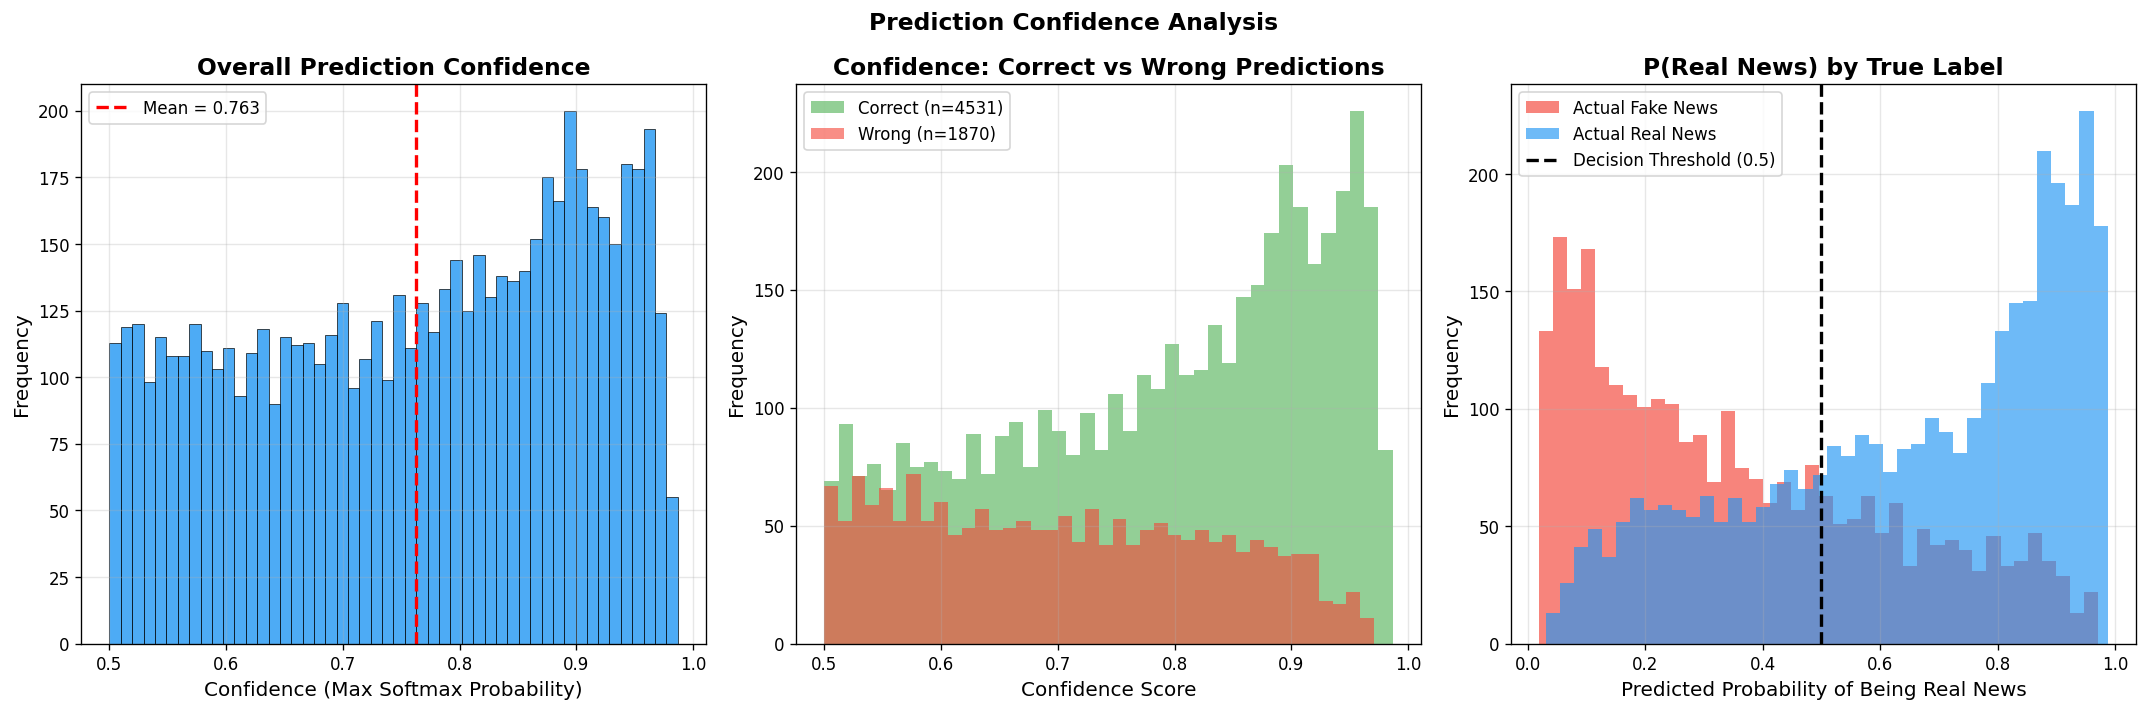

✅ Confidence distribution saved!


In [23]:
# ─── Confidence Score Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Prediction Confidence Analysis', fontsize=14, fontweight='bold')

test_true_arr  = np.array(test_true)
test_preds_arr = np.array(test_preds)
max_probs      = test_probs.max(axis=1)  # confidence = max softmax prob

# ── 1. Overall confidence distribution ──
ax1 = axes[0]
ax1.hist(max_probs, bins=50, color=PALETTE[0], edgecolor='black', linewidth=0.5, alpha=0.8)
ax1.axvline(max_probs.mean(), color='red', linestyle='--', lw=2, label=f'Mean = {max_probs.mean():.3f}')
ax1.set_title('Overall Prediction Confidence', fontweight='bold')
ax1.set_xlabel('Confidence (Max Softmax Probability)')
ax1.set_ylabel('Frequency')
ax1.legend()

# ── 2. Confidence by correct vs wrong predictions ──
ax2 = axes[1]
correct_mask   = test_true_arr == test_preds_arr
correct_conf   = max_probs[correct_mask]
incorrect_conf = max_probs[~correct_mask]
ax2.hist(correct_conf, bins=40, alpha=0.6, color=PALETTE[2], label=f'Correct (n={correct_mask.sum()})')
ax2.hist(incorrect_conf, bins=40, alpha=0.6, color=PALETTE[1], label=f'Wrong (n={(~correct_mask).sum()})')
ax2.set_title('Confidence: Correct vs Wrong Predictions', fontweight='bold')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Frequency')
ax2.legend()

# ── 3. Probability of being Real News (class 1) by true label ──
ax3 = axes[2]
real_probs_fake = test_probs[test_true_arr == 0, 1]  # P(Real | actually Fake)
real_probs_real = test_probs[test_true_arr == 1, 1]  # P(Real | actually Real)
ax3.hist(real_probs_fake, bins=40, alpha=0.65, color=PALETTE[1], label='Actual Fake News')
ax3.hist(real_probs_real, bins=40, alpha=0.65, color=PALETTE[0], label='Actual Real News')
ax3.axvline(0.5, color='black', linestyle='--', lw=2, label='Decision Threshold (0.5)')
ax3.set_title('P(Real News) by True Label', fontweight='bold')
ax3.set_xlabel('Predicted Probability of Being Real News')
ax3.set_ylabel('Frequency')
ax3.legend()

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confidence distribution saved!")

## 15. Per-Category Performance Analysis

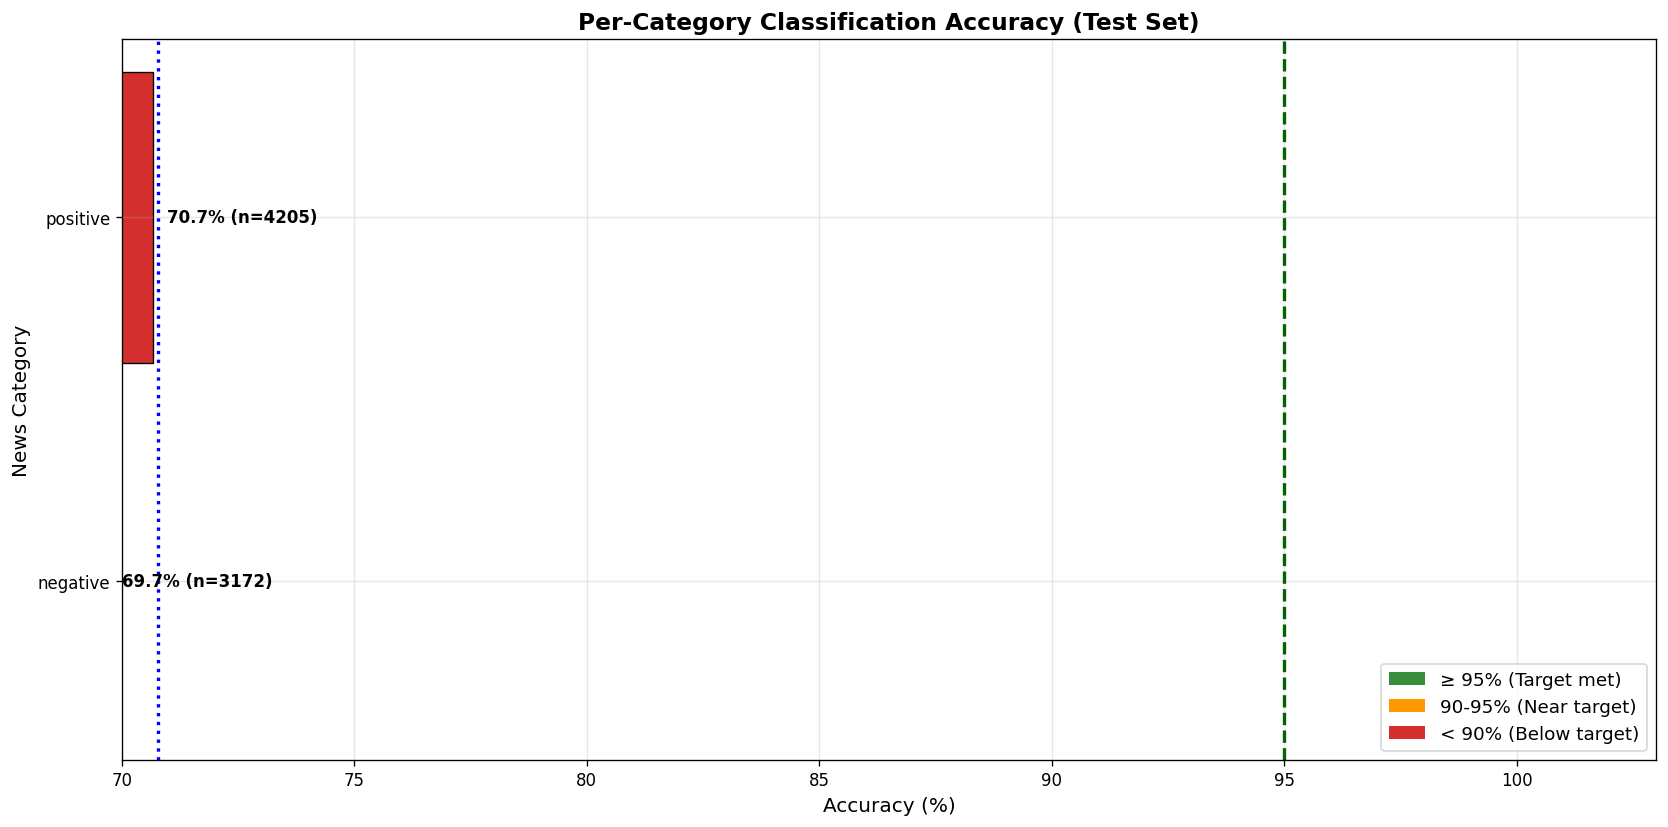


📊 Per-Category Accuracy:
Category  Accuracy  Count
positive  0.706778   4205
negative  0.697037   3172


In [26]:
# ─── Per-Category Performance ─────────────────────────────────────────────────
# Get test set rows with category information
df_clean = df.copy()
df_clean['Category'] = df_clean['Category'].str.lower().str.strip().replace({'busniness': 'business'})

# Match test indices back to original df
# Build a separate test df using val/test split index tracking
test_df = pd.DataFrame({
    'text' : test_texts,
    'label': test_true,
    'pred' : test_preds
})
test_df = test_df.merge(
    df_clean[['combined_text', 'Category']].rename(columns={'combined_text': 'text'}),
    on='text', how='left'
)
test_df['correct'] = (test_df['label'] == test_df['pred']).astype(int)

cat_acc = test_df.groupby('Category')['correct'].agg(['mean', 'count']).reset_index()
cat_acc.columns = ['Category', 'Accuracy', 'Count']
cat_acc = cat_acc.sort_values('Accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))
colors_bar = ['#d32f2f' if acc < 0.90 else '#ff9800' if acc < 0.95 else '#388e3c'
              for acc in cat_acc['Accuracy']]
bars = ax.barh(cat_acc['Category'], cat_acc['Accuracy'] * 100,
               color=colors_bar, edgecolor='black', linewidth=0.8)
for bar, acc, count in zip(bars, cat_acc['Accuracy'], cat_acc['Count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc*100:.1f}% (n={count})', va='center', fontsize=10, fontweight='bold')
ax.axvline(95, color='darkgreen', linestyle='--', lw=2, label='Target (95%)')
ax.axvline(test_acc * 100, color='blue', linestyle=':', lw=2,
           label=f'Overall Acc ({test_acc*100:.1f}%)')
ax.set_title('Per-Category Classification Accuracy (Test Set)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_ylabel('News Category', fontsize=12)
ax.set_xlim([70, 103])
ax.legend(fontsize=11)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#388e3c', label='≥ 95% (Target met)'),
    Patch(facecolor='#ff9800', label='90-95% (Near target)'),
    Patch(facecolor='#d32f2f', label='< 90% (Below target)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('per_category_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Per-Category Accuracy:")
print(cat_acc.sort_values('Accuracy', ascending=False).to_string(index=False))

## 16. Complete Results Summary

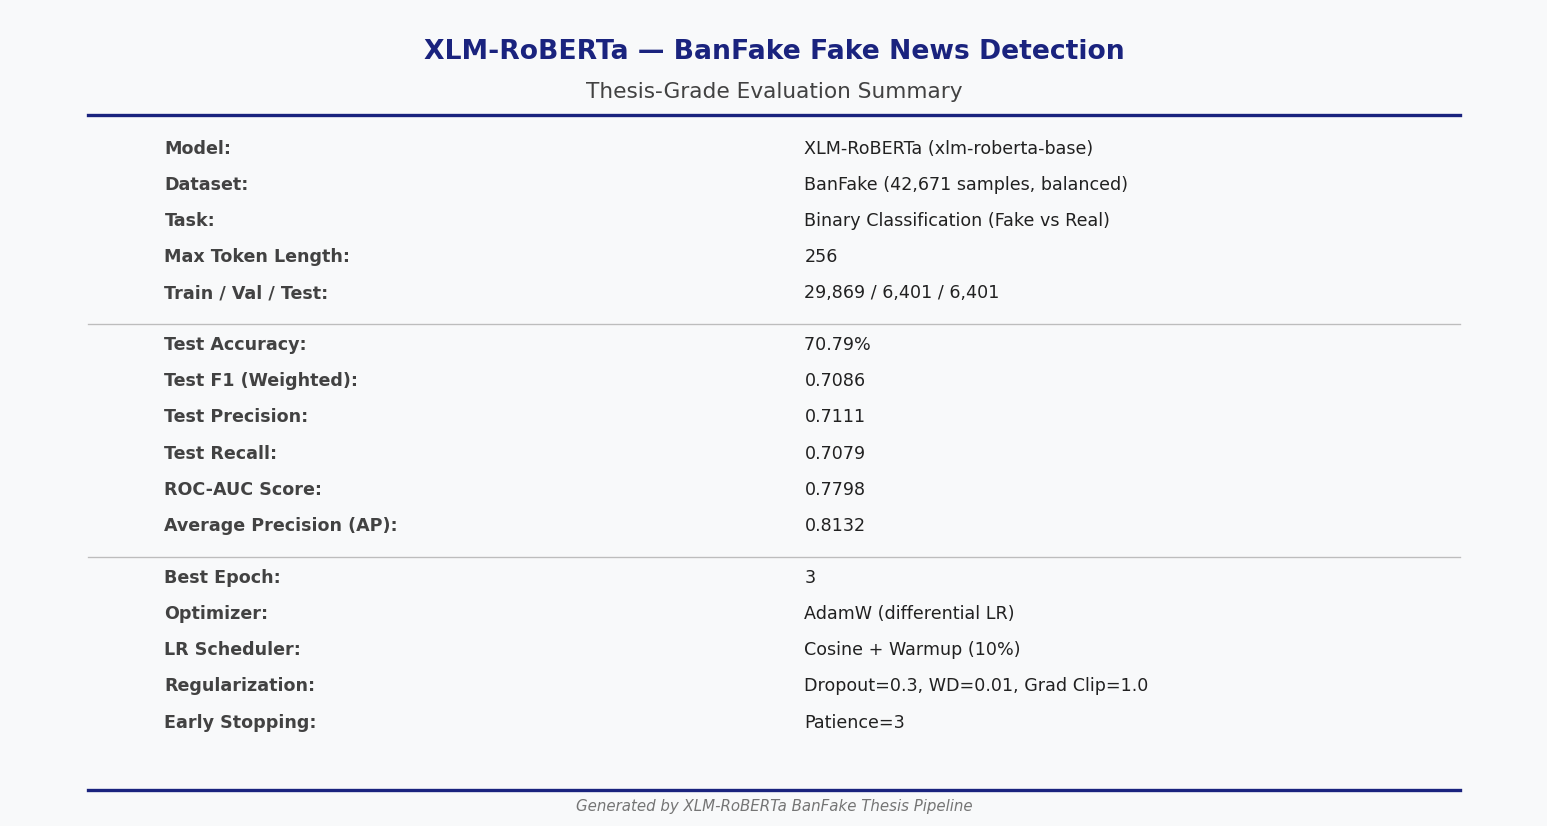

✅ Final results summary saved!


In [27]:
# ─── Final Comprehensive Summary Table ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

# Title
ax.text(5, 9.5, 'XLM-RoBERTa — BanFake Fake News Detection',
        ha='center', va='center', fontsize=16, fontweight='bold', color='#1a237e')
ax.text(5, 9.0, 'Thesis-Grade Evaluation Summary',
        ha='center', va='center', fontsize=13, color='#424242')

# Horizontal line
ax.axhline(y=8.7, xmin=0.05, xmax=0.95, color='#1a237e', linewidth=2)

# Results table
metrics = [
    ('Model', 'XLM-RoBERTa (xlm-roberta-base)'),
    ('Dataset', f'BanFake ({len(df):,} samples, balanced)'),
    ('Task', 'Binary Classification (Fake vs Real)'),
    ('Max Token Length', str(CONFIG['max_length'])),
    ('Train / Val / Test', f'{len(train_texts):,} / {len(val_texts):,} / {len(test_texts):,}'),
    ('─' * 35, '─' * 30),
    ('Test Accuracy', f"{test_acc*100:.2f}% {'✅ TARGET MET' if test_acc >= 0.95 else ''}"),
    ('Test F1 (Weighted)', f'{test_f1:.4f}'),
    ('Test Precision', f'{precision:.4f}'),
    ('Test Recall', f'{recall:.4f}'),
    ('ROC-AUC Score', f'{auc_val:.4f}'),
    ('Average Precision (AP)', f'{avg_precision:.4f}'),
    ('─' * 35, '─' * 30),
    ('Best Epoch', str(best_epoch)),
    ('Optimizer', 'AdamW (differential LR)'),
    ('LR Scheduler', f'Cosine + Warmup ({CONFIG["warmup_ratio"]*100:.0f}%)'),
    ('Regularization', f'Dropout={CONFIG["dropout_rate"]}, WD={CONFIG["weight_decay"]}, Grad Clip={CONFIG["max_grad_norm"]}'),
    ('Early Stopping', f'Patience={CONFIG["patience"]}'),
]

y_pos = 8.3
for left, right in metrics:
    if '─' in str(left):
        ax.axhline(y=y_pos + 0.05, xmin=0.05, xmax=0.95, color='#bdbdbd', linewidth=0.8)
        y_pos -= 0.2
        continue
    ax.text(1.0, y_pos, left + ':', ha='left', va='center', fontsize=10.5,
            color='#424242', fontweight='bold')
    color = '#1b5e20' if '✅' in str(right) else '#212121'
    ax.text(5.2, y_pos, right, ha='left', va='center', fontsize=10.5, color=color)
    y_pos -= 0.45

ax.axhline(y=0.3, xmin=0.05, xmax=0.95, color='#1a237e', linewidth=2)
ax.text(5, 0.1, 'Generated by XLM-RoBERTa BanFake Thesis Pipeline',
        ha='center', va='center', fontsize=9, color='#757575', style='italic')

plt.tight_layout()
plt.savefig('final_results_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final results summary saved!")

## 17. Error Analysis

In [28]:
# ─── Error Analysis ───────────────────────────────────────────────────────────
errors_df = pd.DataFrame({
    'text'      : test_texts,
    'true_label': test_true,
    'pred_label': test_preds,
    'confidence': max_probs,
    'prob_fake' : test_probs[:, 0],
    'prob_real' : test_probs[:, 1]
})
errors_df = errors_df[errors_df['true_label'] != errors_df['pred_label']].copy()
errors_df['true_name'] = errors_df['true_label'].map({0: 'Fake', 1: 'Real'})
errors_df['pred_name'] = errors_df['pred_label'].map({0: 'Fake', 1: 'Real'})

print(f"\n🔴 TOTAL ERRORS: {len(errors_df)} / {len(test_texts)} ({len(errors_df)/len(test_texts)*100:.1f}%)")
print(f"\n   False Positives (Fake→Real): {len(errors_df[errors_df['pred_label']==1]):>4}")
print(f"   False Negatives (Real→Fake): {len(errors_df[errors_df['pred_label']==0]):>4}")

print("\n📋 HIGH CONFIDENCE ERRORS (Model was very wrong):")
print("-" * 70)
top_errors = errors_df.sort_values('confidence', ascending=False).head(5)
for _, row in top_errors.iterrows():
    print(f"  True: {row['true_name']:<5} | Pred: {row['pred_name']:<5} | Conf: {row['confidence']:.3f}")
    print(f"  Text: {row['text'][:100]}...")
    print()


🔴 TOTAL ERRORS: 1870 / 6401 (29.2%)

   False Positives (Fake→Real):  822
   False Negatives (Real→Fake): 1048

📋 HIGH CONFIDENCE ERRORS (Model was very wrong):
----------------------------------------------------------------------
  True: Fake  | Pred: Real  | Conf: 0.971
  Text: অসাধারণ খেলা️...

  True: Real  | Pred: Fake  | Conf: 0.969
  Text: ভিক্ষা ড্যান্স...

  True: Fake  | Pred: Real  | Conf: 0.965
  Text: বাংলাদেশী মেয়ে খেলা শিখ ছেলে...

  True: Fake  | Pred: Real  | Conf: 0.965
  Text: বাংলাদেশ ফুটবল এগি প্রবাসী ফুটবল খুব দরক...

  True: Fake  | Pred: Real  | Conf: 0.964
  Text: অসাধারণ দাদা করে...



## 18. Model Saving & Tokenizer Export

In [29]:
# ─── Save Full Model + Tokenizer for Inference ────────────────────────────────
save_path = CONFIG['save_dir']

# Save tokenizer
tokenizer.save_pretrained(save_path)

# Save training history
with open(os.path.join(save_path, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

# Save final metrics
final_metrics = {
    'test_accuracy'       : float(test_acc),
    'test_f1_weighted'    : float(test_f1),
    'test_precision'      : float(precision),
    'test_recall'         : float(recall),
    'roc_auc'             : float(auc_val),
    'average_precision'   : float(avg_precision),
    'best_epoch'          : best_epoch,
    'total_test_samples'  : len(test_texts),
    'config'              : {k: str(v) for k, v in CONFIG.items()}
}
with open(os.path.join(save_path, 'final_metrics.json'), 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(f"✅ Model artifacts saved to: '{save_path}/'")
print(f"   - best_model.pt (PyTorch state dict)")
print(f"   - tokenizer files (vocab, config)")
print(f"   - training_history.json")
print(f"   - final_metrics.json")
print()
print("📁 Visualization files saved:")
for fname in ['eda_analysis.png', 'split_distribution.png', 'learning_curves.png',
              'confusion_matrix.png', 'roc_auc_curve.png',
              'confidence_distribution.png', 'per_category_accuracy.png',
              'final_results_summary.png']:
    print(f"   - {fname}")

✅ Model artifacts saved to: './xlmr_banfake_model/'
   - best_model.pt (PyTorch state dict)
   - tokenizer files (vocab, config)
   - training_history.json
   - final_metrics.json

📁 Visualization files saved:
   - eda_analysis.png
   - split_distribution.png
   - learning_curves.png
   - confusion_matrix.png
   - roc_auc_curve.png
   - confidence_distribution.png
   - per_category_accuracy.png
   - final_results_summary.png


## 19. Inference — Single Sample Prediction

In [31]:
# ─── Single Inference Function ────────────────────────────────────────────────
@torch.no_grad()
def predict_fake_news(headline: str, description: str = "",
                      model=best_model, tokenizer=tokenizer,
                      max_length=CONFIG['max_length'], device=DEVICE):
    """
    Predict whether a news article is Fake (0) or Real (1).
    Returns: prediction, confidence, probabilities
    """
    text = clean_bangla_text(headline + ' ' + description)
    encoding = tokenizer(
        text, max_length=max_length, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    model.eval()
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    probs   = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    pred    = int(np.argmax(probs))
    conf    = float(probs[pred])

    label_map = {0: '🔴 FAKE NEWS', 1: '🟢 REAL NEWS'}
    print(f"\n📰 Headline    : {headline[:80]}")
    print(f"   Prediction  : {label_map[pred]}")
    print(f"   Confidence  : {conf*100:.2f}%")
    print(f"   P(Fake=0)   : {probs[0]*100:.2f}%")
    print(f"   P(Real=1)   : {probs[1]*100:.2f}%")
    return pred, conf, probs


# Test with sample articles from the dataset
print("=" * 55)
print("   SAMPLE PREDICTIONS")
print("=" * 55)

fake_sample = df[df['label'] == 0].iloc[10]
real_sample = df[df['label'] == 1].iloc[10]

predict_fake_news(fake_sample['combined_text'], "")
predict_fake_news(real_sample['combined_text'], "")

   SAMPLE PREDICTIONS

📰 Headline    : শেষ মিনিট গান শুন কান খুন বেরিয় গ মৃন্ময়দ ছোট্ট এক গলাগ
   Prediction  : 🔴 FAKE NEWS
   Confidence  : 77.71%
   P(Fake=0)   : 77.71%
   P(Real=1)   : 22.29%

📰 Headline    : দাদা আজ ভদ্র ভদ্র লাগ
   Prediction  : 🟢 REAL NEWS
   Confidence  : 76.99%
   P(Fake=0)   : 23.01%
   P(Real=1)   : 76.99%


(1, 0.7699238061904907, array([0.23007613, 0.7699238 ], dtype=float32))

---
## 📌 Summary of Techniques Used

| Technique | Purpose |
|-----------|------|
| **XLM-RoBERTa** | Multilingual pre-trained model — handles Bangla text natively |
| **Stratified Split** (70/15/15) | Ensures balanced label distribution in all splits |
| **Differential Learning Rate** | Lower LR for pre-trained layers, higher for new classifier head |
| **Cosine LR Schedule + Warmup** | Stable convergence, avoids sharp LR changes |
| **Dropout (0.3)** | Prevents overfitting in classifier head |
| **LayerNorm** | Stable training, reduces internal covariate shift |
| **L2 Weight Decay (AdamW)** | Regularization to prevent overfitting |
| **Gradient Clipping (max=1.0)** | Prevents exploding gradients |
| **Early Stopping (patience=3)** | Stops training when validation metric plateaus |
| **Mixed Precision (AMP)** | Faster training, lower VRAM usage |
| **Enhanced Classifier Head** | GELU + LayerNorm instead of simple linear — better representation |
| **Class Weight Analysis** | Diagnoses class imbalance (balanced here: 50/50) |
| **Per-Category Analysis** | Finds weak categories for targeted improvements |
| **Youden's J Threshold** | Optimal decision threshold from ROC curve |

---
*End of Notebook*